# 1 &middot; Building the Deformation Gradient

Every tutorial after this one leans on one object: the **deformation gradient**
\(F\). Before we *use* it, let's *build* it, so it never feels like it appears
by magic.

A deformation is a map \(\phi\) that takes each material (rest) point
\(X\) to a deformed point \(x = \phi(X)\). The deformation gradient is its
Jacobian,
$$ F = \frac{\partial x}{\partial X}, $$
a local linear map that says how a tiny chunk of material around \(X\) is
stretched and rotated. For a single triangle the map is **affine**,
\(x = F X + t\), so \(F\) is one constant \(2\times 2\) matrix we can solve
for directly.

In [1]:
# --- make the *local* simkit (this repo) importable, ahead of any installed copy ---
import sys, os
sys.path.insert(0, os.path.abspath(os.path.join(os.getcwd(), "..", "..")))
%matplotlib inline
import numpy as np
import matplotlib.pyplot as plt
import simkit
import simkit.energies as energies
import utils
os.makedirs("media", exist_ok=True)

ModuleNotFoundError: No module named 'matplotlib'

## Eliminate the translation with edge vectors

If \(x = F X + t\), then subtracting vertex 0 from vertices 1 and 2 cancels the
unknown translation \(t\):
$$ x_i - x_0 = F\,(X_i - X_0). $$
Stack the two rest edges as columns of \(D_m = [\,X_1-X_0,\; X_2-X_0\,]\) and the
two deformed edges as \(D_s = [\,x_1-x_0,\; x_2-x_0\,]\). Then \(D_s = F D_m\),
so
$$ \boxed{\,F = D_s\, D_m^{-1}\,}. $$
That's the whole thing &mdash; two edge matrices and one inverse.

In [ ]:
def deformation_gradient_triangle(X, U):
    """F for a single triangle, built from rest edges (X) and deformed edges (U)."""
    Dm = np.column_stack([X[1] - X[0], X[2] - X[0]])   # rest edge vectors
    Ds = np.column_stack([U[1] - U[0], U[2] - U[0]])   # deformed edge vectors
    return Ds @ np.linalg.inv(Dm)

# rest triangle (equilateral, side 1)
X = np.array([[-0.5, 0.0], [0.5, 0.0], [0.0, np.sqrt(3) / 2]])

# sanity checks ---------------------------------------------------------------
print("rest -> rest gives the identity:\n", np.round(deformation_gradient_triangle(X, X), 6))

theta = np.deg2rad(30)
R = np.array([[np.cos(theta), -np.sin(theta)], [np.sin(theta), np.cos(theta)]])
U_rot = (X @ R.T) + np.array([2.0, -1.0])          # rotate AND translate
print("\nrotate 30 deg + translate -> F is exactly that rotation:\n",
      np.round(deformation_gradient_triangle(X, U_rot), 6))

rest -> rest gives the identity:
 [[1. 0.]
 [0. 1.]]

rotate 30 deg + translate -> F is exactly that rotation:
 [[ 0.866025 -0.5     ]
 [ 0.5       0.866025]]


Two things already stand out:

* **Translation drops out.** We built \(F\) from *edges*, and translating every
  vertex leaves the edges unchanged. So \(F\) is blind to where the triangle
  sits &mdash; only its shape matters.
* A **rotation** maps to a rotation matrix \(F = R\) (and \(\det F = 1\): no area
  change).

## The same thing, for any simplex: `simkit.deformation_gradient`

SimKit generalizes this to triangles *and* tetrahedra with a reference-element
shape-function gradient (the matrix `H`), but it computes exactly the same
\(F\). Let's confirm our hand-built version matches it.

In [ ]:
T = np.array([[0, 1, 2]])                  # one triangle, vertices 0,1,2

ours    = deformation_gradient_triangle(X, U_rot)
simkit_F = simkit.deformation_gradient(X, T, U_rot)[0]    # [0] = first (only) element

print("match:", np.allclose(ours, simkit_F))
print(np.round(simkit_F, 6))

match: True
[[ 0.866025 -0.5     ]
 [ 0.5       0.866025]]


## Seeing it

The rest triangle (dashed) and three deformed versions, each labelled with the
\(F\) we just built. Note the rotate-*and*-translate case: a big translation, yet
\(F\) is still a pure rotation with \(\det F = 1\).

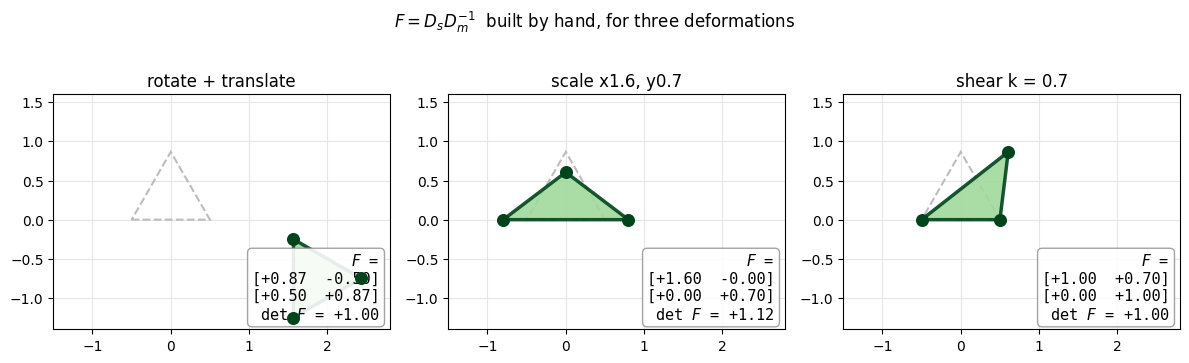

In [ ]:
cases = [("rotate + translate", U_rot),
         ("scale x1.6, y0.7",   X * np.array([1.6, 0.7])),
         ("shear k = 0.7",      X @ np.array([[1.0, 0.7], [0.0, 1.0]]).T)]
fig, axes = plt.subplots(1, 3, figsize=(12, 3.8))
for ax, (name, U) in zip(axes, cases):
    utils.setup_axes(ax, (-1.5, 2.8), (-1.4, 1.6), title=name)
    utils.TriangleArtist(ax, U, rest=X)
    utils.text_box(ax, utils.format_F(deformation_gradient_triangle(X, U)), loc="lower right")
fig.suptitle(r"$F = D_s D_m^{-1}$  built by hand, for three deformations")
fig.tight_layout(); plt.show()

### Takeaways
* \(F = D_s D_m^{-1}\): the deformed edges expressed in the rest-edge basis.
* It is the **local linear part** of the deformation &mdash; translation-free by
  construction.
* `simkit.deformation_gradient(X, T, U)` returns one \(F\) per element and is
  what every later tutorial calls.

Next we build intuition for what different \(F\)'s *look like*.